# Mean-curvature preference and accommodation training

Fit an equal-cell graph energy to physical, baseline-residual mean curvature. The local preference combines size-independent center identity with saturating two-hop fate responses. Pair amplitudes are affine in log N; accommodation is softplus-affine in log N. Hop 2 has exactly half the absolute hop-1 amplitude, with a training-selected relative sign. Saturation and relative signs are constant across N. No measured neighbor curvature or cell-patch area is used.

Reuse the previous mean-target cleanup, baselines and all five saved outer folds. Train center-only and linear controls, learned-activation models with/without accommodation, and a fresh depth-2 zero-mask FiLM reference on matching physical targets. FiLM retains the original reference architecture, optimization protocol and model-specific asinh target scaling. All models, baselines, transforms, splits, inner memberships and optimizer diagnostics are saved under `training_results/mean_curvature_energy_training/`. The evaluation notebook restores these artifacts independently.

Role: training; fit and save models on fixed saved folds.

The fitted residual field solves $(I+\lambda L)h=u$, where $L$ is the unweighted adjacency Laplacian, $u$ contains the local preferences, and the saved organoid baseline is added to $h$ for full mean-curvature predictions. Accommodation can therefore transmit a local preference beyond the two-hop fate neighborhood.

| Variant | Local preference $u$ | Accommodation |
| --- | --- | --- |
| `center_local` | Center identity only | None |
| `center_accommodated` | Center identity only | Fitted $\lambda(N)$ |
| `linear_accommodated` | Center identity plus linear two-hop fate responses | Fitted $\lambda(N)$ |
| `learned_local` | Center identity plus learned saturating two-hop fate responses | None |
| `learned_accommodated` | Center identity plus learned saturating two-hop fate responses | Fitted $\lambda(N)$ |

In every pair model, amplitudes depend affinely on log N and hop 2 has exactly half the absolute hop-1 amplitude. Center preferences, saturation parameters and relative hop signs remain constant in N. `FiLM` is the separately trained mean-curvature accuracy reference.


In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').exists())  # Project root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED
import copy
import gc
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython
from IPython.display import display
from src.artifacts.bundle import load_bundle, save_bundle, graph_membership
from src.artifacts.checkpoints import model_spec, build_model
from src.artifacts.runs import AnalysisRun
from src.artifacts.paths import training_run_path
from src.artifacts.provenance import workflow_fingerprint
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import fit_energy, energy_mse
from src.models.curvature_energy import graph_laplacian
from src.training.progress import TrainingProgress
from src.training.masking import MaskTrainingConfig, inner_split, train_mask_model
from src.models.size_models import seed_all
from src.data.target_transforms import AsinhStandardizeTransform
from src.data.fate_masking import encode_fates
from src.inference.predict import predict_targets
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
torch.set_num_threads(4)


## Settings
Configure the run before any data loading or training. Data selection and preprocessing are inherited from the saved source; there are no separate train/validation timepoint selectors.

In [2]:
# Saved data and execution
SOURCE_RUN = 'activation_curvatures_20260928_170831'  # Saved mean targets, baselines and exact outer folds.
RESUME_RUN = 'training_results/mean_curvature_energy_training/logN_signed_half_hop_20260929_145842'  # Existing output path to resume; None creates a new run.
RUN_TRAINING = True  # Fit missing models; existing verified checkpoints are reused.
CONCURRENT_FITS = 2  # Independent CPU energy fits; each uses blas_threads cores.
SHOW_PROGRESS = True  # Display the overall model/fold progress panel.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # FiLM training device; energy solves use CPU.

SETTINGS = dict(
    # Run identity and shared data
    tag='logN_signed_half_hop',  # Descriptive run tag.
    target_indices=[1],  # Mean curvature only.
    seed=42,  # Initialization and energy inner-split seed.
    target_scaling='identity',  # Energy uses physical baseline residuals; FiLM uses its saved asinh transform.
    residualize=True,  # Reuse the saved mean-curvature baseline subtraction.
    exclusive_markers=True,  # Saved exclusive fates; all-zero rows represent Unassigned.

    # Energy model and activation
    size_dependent=True,  # Affine log-N pair amplitudes and softplus-affine accommodation.
    fixed_alpha=3.,  # Reference/shrinkage value for learned saturation.
    min_pair_organoids=20,  # Required training-organism support for learned activation and relative sign.
    variants=['center_local','center_accommodated','linear_accommodated','learned_local','learned_accommodated'],  # Interpretable controls and main model.

    # Energy fitting and training-only model selection
    inner_fraction=.2,  # Organoid holdout within each outer training fold for penalty selection.
    pair_ridge_grid=[.0001,.001],  # Candidate pair coefficient penalties.
    ridge=.0001,  # Center coefficient penalty.
    slope_ridge=.001,  # Extra penalty on affine pair slopes.
    lambda_ridge=.0001,  # Accommodation magnitude penalty.
    alpha_ridge=.00001,  # Log-saturation shrinkage toward fixed_alpha.
    starts=[[.15,3.,1],[.8,10.,-1]],  # Initial accommodation, saturation and relative hop sign.
    max_iterations=250,  # Continuous optimization iterations per sign round.
    tolerance=.00002,  # Projected-gradient convergence tolerance.
    blas_threads=4,  # CPU linear-algebra threads.

    # Matched FiLM reference
    film_depth=2,  # Reference message-passing depth.
    film_width=128,  # Reference hidden width; architecture and optimizer copied from the original zero-mask run.
)


## Restore the data and baselines
Verify exact organoid membership and copy self-contained input bundles. Existing checkpoints are verified on resume. Per-cell areas are never model inputs; the inherited global baseline retains its original organoid-level global features.

In [3]:
source = AnalysisRun(PROJECT_ROOT/'training_results/coupled_fate_training'/SOURCE_RUN)
reference = AnalysisRun(source.settings['reference_run'])
membership = json.loads((source.directory/'splits.json').read_text())
if membership!=json.loads((reference.directory/'splits.json').read_text()):raise ValueError('Reference fold mismatch')
cohort = load_bundle(source.directory/'cohort')
marker_names = list(cohort['all_marker_names'])
SETTINGS.update(source_run=str(source.directory),reference_run=str(reference.directory),dataset=source.settings['dataset'],
    baseline_features=reference.settings['baseline_features'],film_settings=reference.settings)
RUN_DIR = Path(RESUME_RUN) if RESUME_RUN else training_run_path(PROJECT_ROOT,'mean_curvature_energy_training',SETTINGS['tag'])
if RUN_TRAINING:
    if RUN_DIR.exists():
        if json.loads((RUN_DIR/'settings.json').read_text())!=json.loads(json.dumps(SETTINGS)):raise ValueError('Resume settings changed')
    else:
        RUN_DIR.mkdir(parents=True)
        (RUN_DIR/'settings.json').write_text(json.dumps(SETTINGS,indent=2))
        (RUN_DIR/'splits.json').write_text(json.dumps(membership,indent=2))
        save_bundle(RUN_DIR/'cohort',cohort,splits=membership)
    (RUN_DIR/'history').mkdir(exist_ok=True)
    provenance=dict(code_sha256=workflow_fingerprint(PROJECT_ROOT/'experiments/training/mean_curvature_energy_training.ipynb'))
    (RUN_DIR/'provenance.json').write_text(json.dumps(provenance,indent=2))
    for split in membership:
        fold=split['fold'];destination=RUN_DIR/f'inputs/fold_{fold}_mean'
        if destination.exists():load_bundle(destination);continue
        inputs=load_bundle(source.directory/f'inputs/fold_{fold}_mean')
        if graph_membership(train=inputs['groups']['train'],validation=inputs['groups']['val'])!={k:split[k] for k in ['train','validation']}:raise ValueError('Input membership mismatch')
        save_bundle(destination,inputs,splits=split,provenance=provenance)
print('Output:',RUN_DIR,'| FiLM device:',DEVICE,flush=True)
display(pd.DataFrame([dict(fold=s['fold'],train=len(s['train']),validation=len(s['validation'])) for s in membership]))


Output: training_results/mean_curvature_energy_training/logN_signed_half_hop_20260929_145842 | FiLM device: cuda


,fold,train,validation
0,0,936,234
1,1,936,234
2,2,936,234
3,3,936,234
4,4,936,234


## Train the matched FiLM reference
Train only on outer-training organoids, with the original inner early-stopping protocol and zero masking. The extra missingness flag remains zero. The physical cleaned targets and baselines match the energy models exactly; asinh scaling is internal to FiLM and reversed for evaluation.

In [4]:
if RUN_TRAINING:
    catalog=RUN_DIR/'models.json'
    records=json.loads(catalog.read_text()) if catalog.exists() else []
    known={r['key'] for r in records}
    for bundle in (RUN_DIR/'models').glob('*'):
        if not (bundle/'manifest.json').exists():continue
        saved=load_bundle(bundle)
        if saved['record']['key'] not in known:
            records.append(saved['record']);known.add(saved['record']['key'])
    catalog.write_text(json.dumps(records,indent=2))
    for record in records:load_bundle(RUN_DIR/record['bundle'])
    fs=reference.settings
    training_config=MaskTrainingConfig(rates=(0.,.05),masked_loss_weight=fs['masked_loss_weight'],inner_val_fraction=fs['inner_val_fraction'],
        inner_split_seed=fs['inner_split_seed'],max_epochs=fs['max_epochs'],patience=fs['patience'],batch_size=fs['batch_size'],num_workers=0,grad_clip=fs['grad_clip'])
    loss_settings=dict(LR=fs['lr'],WEIGHT_DECAY=fs['weight_decay'],EDGE_LOSS_WEIGHT=fs['edge_loss_weight'],EDGE_LOSS_PARAMS=fs['edge_loss_params'])
    progress=TrainingProgress(len(membership)*(1+len(SETTINGS['variants'])),show=SHOW_PROGRESS,log_path=RUN_DIR/'training_progress.csv')
    for split in membership:
        fold=split['fold'];key=f'film_mean_d{SETTINGS["film_depth"]}_f{fold}_s{SETTINGS["seed"]}'
        with progress.task(model='FiLM mean curvature',depth=SETTINGS['film_depth'],fold=fold,seed=SETTINGS['seed']):
            if key in known:continue
            inputs=load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean');film_path=RUN_DIR/f'inputs/fold_{fold}_film'
            fit_ids,early_ids=inner_split(len(inputs['groups']['train']),fs['inner_val_fraction'],fs['inner_split_seed']+fold)
            if film_path.exists():film_inputs=load_bundle(film_path)
            else:
                original=load_bundle(reference.directory/f'inputs/fold_{fold}_all_observed')
                globals_by_id={g.organoid_str:g.global_feat.clone() for group in original['groups'].values() for g in group}
                film_inputs=copy.deepcopy(inputs)
                transform=AsinhStandardizeTransform(robust=True).fit(film_inputs['groups']['train'])
                for group in film_inputs['groups'].values():
                    transform.transform_graphs(group,in_place=True)
                    for g in group:
                        g.y=g.y.reshape(-1).float();g.x=encode_fates(g.x.float());g.global_feat=globals_by_id[g.organoid_str]
                film_inputs.update(transform=transform,global_features=['log_num_cells'],global_center=original['global_center'],global_scale=original['global_scale'],
                    inner_membership=dict(train=[inputs['groups']['train'][i].organoid_str for i in fit_ids],validation=[inputs['groups']['train'][i].organoid_str for i in early_ids]),
                    input_encoding='exclusive fate vector plus observed zero missingness flag')
                save_bundle(film_path,film_inputs,splits=split,provenance=provenance)
            fit=[copy.deepcopy(film_inputs['groups']['train'][i]) for i in fit_ids];early=[copy.deepcopy(film_inputs['groups']['train'][i]) for i in early_ids]
            for g in fit+early:g.x=g.x[:,:len(marker_names)].clone()
            candidates=reference.records[(reference.records.name=='film')&(reference.records.rate==0)&(reference.records.depth==SETTINGS['film_depth'])&(reference.records.hidden_dim==SETTINGS['film_width'])&(reference.records.fold==fold)&(reference.records.seed==SETTINGS['seed'])]
            if len(candidates)!=1:raise ValueError('Ambiguous original FiLM architecture')
            old=load_bundle(reference.directory/candidates.iloc[0].bundle)['model'];spec=model_spec(old);del old
            seed_all(SETTINGS['seed']);model=build_model(spec)
            def epoch_status(event):
                if event['epoch']%10==0:print(f"FiLM fold {fold}; completed {len(records)}/{len(membership)*(1+len(SETTINGS['variants']))}; epoch {event['epoch']}; inner score {event['value']:.5g}",flush=True)
            model,history=train_mask_model(model,fit,early,loss_settings,training_config,rate=0.,seed=SETTINGS['seed'],device=DEVICE,verbose=False,epoch_callback=epoch_status)
            record=dict(key=key,name='FiLM',depth=SETTINGS['film_depth'],fold=fold,seed=SETTINGS['seed'],target_indices=[1],subset='all',signal='intact',rate=0.,hidden_dim=SETTINGS['film_width'],bundle=f'models/{key}',input_bundle=f'inputs/fold_{fold}_film',family='film')
            save_bundle(RUN_DIR/record['bundle'],dict(model=model.cpu(),record=record,history=history),splits=split,provenance=provenance)
            history.to_csv(RUN_DIR/'history'/f'{key}.csv',index=False);records.append(record);known.add(key)
            catalog.write_text(json.dumps(records,indent=2))
            print('Saved',key,flush=True)
            del model,fit,early,film_inputs,inputs;gc.collect();torch.cuda.empty_cache()


## Fit local preferences and accommodation
Select regularization on a training-only inner holdout, then refit on the full outer-training fold. For each continuous fit, alternate with coordinate-wise sign selection; multiple starts address some local optima, without guaranteeing a global optimum. The first-hop coefficient table retains training-weighted zero row/column means; hop 2 is derived and has no independent table.

In [5]:
if RUN_TRAINING:
    # All fitting tasks read the same immutable per-fold samples; one writer publishes the catalog.
    sample_cache={};tasks=[];status={}
    for split in membership:
        fold=split['fold']
        pending=[v for v in SETTINGS['variants'] if f'{v}_f{fold}_s{SETTINGS["seed"]}' not in known]
        if not pending:continue
        inputs=load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean');samples={}
        for role,group in inputs['groups'].items():
            flat=copy.deepcopy(group)
            for g in flat:g.y=g.y.reshape(-1)
            samples[role]=graph_samples(flat,2)
            for s in samples[role]:s['laplacian']=graph_laplacian(s['transition'])
        sample_cache[fold]=samples
        tasks.extend((split,v) for v in pending)
        del inputs,flat
    tasks.sort(key=lambda item:(item[1]=='learned_accommodated',item[1]=='learned_local',item[1]=='linear_accommodated'),reverse=True)
    (RUN_DIR/'execution_settings.json').write_text(json.dumps(dict(concurrent_fits=CONCURRENT_FITS,blas_threads=SETTINGS['blas_threads']),indent=2))

    def fit_one(split,variant):
        fold=split['fold'];key=f'{variant}_f{fold}_s{SETTINGS["seed"]}';samples=sample_cache[fold];started=time.monotonic()
        model_settings=dict(n_markers=len(marker_names),pairs=not variant.startswith('center'),accommodation=variant.endswith('accommodated'),
            activation='learned' if variant.startswith('learned') else 'linear',size_dependent=SETTINGS['size_dependent'],fixed_alpha=SETTINGS['fixed_alpha'],min_pair_organoids=SETTINGS['min_pair_organoids'])
        penalties=[dict(ridge=SETTINGS['ridge'],pair_ridge=p,slope_ridge=SETTINGS['slope_ridge'],lambda_ridge=SETTINGS['lambda_ridge'],alpha_ridge=SETTINGS['alpha_ridge']) for p in (SETTINGS['pair_ridge_grid'] if model_settings['pairs'] else SETTINGS['pair_ridge_grid'][:1])]
        def stage(message):
            status[key]=(started,message)
            print(f'{key}: {message}',flush=True)
        model,metrics,trials=fit_energy(samples['train'],model_settings=model_settings,penalties=penalties,seed=SETTINGS['seed'],inner_fraction=SETTINGS['inner_fraction'],
            starts=SETTINGS['starts'],max_iterations=SETTINGS['max_iterations'],tolerance=SETTINGS['tolerance'],blas_threads=SETTINGS['blas_threads'],callback=stage)
        record=dict(key=key,name=variant,depth=model.radius,fold=fold,seed=SETTINGS['seed'],target_indices=[1],subset='all',signal='intact',bundle=f'models/{key}',input_bundle=f'inputs/fold_{fold}_mean',family='energy')
        metrics['fit_seconds']=time.monotonic()-started
        save_bundle(RUN_DIR/record['bundle'],dict(model=model,record=record,metrics=metrics),splits=split,provenance=provenance)
        trials.to_json(RUN_DIR/'history'/f'{key}.json',orient='records',indent=2)
        return record,float(energy_mse(model,samples['val']).mean())

    # Include verified previous energy checkpoints in the progress count on resume.
    for record in records:
        if record['family']=='energy':
            with progress.task(model=record['name'],depth=record['depth'],fold=record['fold'],seed=record['seed']):pass
    with ThreadPoolExecutor(max_workers=CONCURRENT_FITS) as pool:
        pending={pool.submit(fit_one,split,variant) for split,variant in tasks}
        while pending:
            done,pending=wait(pending,timeout=1,return_when=FIRST_COMPLETED)
            for future in done:
                record,mse=future.result();records.append(record);known.add(record['key']);status.pop(record['key'],None)
                catalog.write_text(json.dumps(records,indent=2))
                with progress.task(model=record['name'],depth=record['depth'],fold=record['fold'],seed=record['seed']):pass
                print(f"Saved {record['key']}; validation MSE {mse:.7f}; completed {len(records)}/{len(membership)*(1+len(SETTINGS['variants']))}",flush=True)
            message=' | '.join(f'{key}: {int(time.monotonic()-start)} s, {text}' for key,(start,text) in list(status.items()))
            progress.stage(message)
    (RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),folds=len(membership)),indent=2))
    print('TRAINING COMPLETE',RUN_DIR,flush=True)


learned_accommodated_f2_s42: Inner penalty 1/2, start 1


learned_accommodated_f1_s42: Inner penalty 1/2, start 1


learned_accommodated_f2_s42: Continuous fit / sign round 1


learned_accommodated_f1_s42: Continuous fit / sign round 1


learned_accommodated_f2_s42: Sign round 1: 18 flips


...

center_accommodated_f4_s42: Sign round 1: 0 flips


center_accommodated_f4_s42: Continuous fit / sign round 1


center_accommodated_f4_s42: Sign round 1: 0 flips


Saved center_accommodated_f4_s42; validation MSE 0.0043830; completed 30/30


TRAINING COMPLETE training_results/mean_curvature_energy_training/logN_signed_half_hop_20260929_145842


## Validation overview and saved handoff
Compare physical mean-curvature MSE with equal organoid weighting and one-SEM bands. The separate evaluation notebook supplies regional comparisons, size trends, fitted coefficients, support diagnostics and the written report.

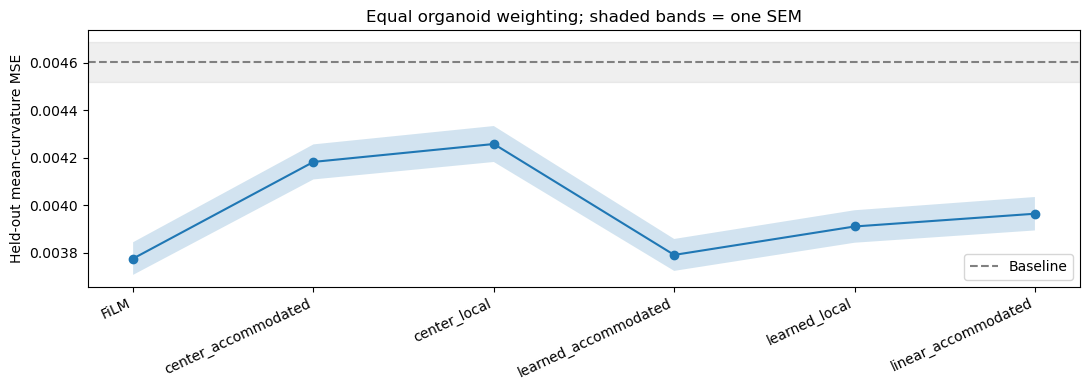

In [6]:
if RUN_TRAINING:
    rows=[]
    for record in records:
        data=load_bundle(RUN_DIR/record['input_bundle']);model=load_bundle(RUN_DIR/record['bundle'])['model']
        physical=load_bundle(RUN_DIR/f'inputs/fold_{record["fold"]}_mean')
        if record['family']=='film':
            _,prediction,_=predict_targets(data['groups']['val'],model,target_transform=data['transform'],device=DEVICE)
            offsets=np.r_[0,np.cumsum([len(g.x) for g in data['groups']['val']])]
            predictions=[np.asarray(prediction)[offsets[i]:offsets[i+1]].reshape(-1) for i in range(len(offsets)-1)]
        else:
            flat=copy.deepcopy(data['groups']['val'])
            for g in flat:g.y=g.y.reshape(-1)
            predictions=[model.predict_sample(s) for s in graph_samples(flat,2)]
        for g,pred in zip(physical['groups']['val'],predictions):
            truth=g.y.numpy().reshape(-1);rows.append(dict(name=record['name'],fold=record['fold'],organoid_str=g.organoid_str,mse=float(np.mean((pred-truth)**2)),baseline_mse=float(np.mean(truth**2))))
    scores=pd.DataFrame(rows);scores.to_csv(RUN_DIR/'validation_mse.csv',index=False)
    summary=scores.groupby('name').mse.agg(['mean','sem']);baseline=scores[scores.name=='FiLM'].baseline_mse
    fig,ax=plt.subplots(figsize=(11,4));x=np.arange(len(summary));ax.plot(x,summary['mean'],'o-');ax.fill_between(x,summary['mean']-summary['sem'],summary['mean']+summary['sem'],alpha=.2)
    ax.axhline(baseline.mean(),color='gray',ls='--',label='Baseline');ax.axhspan(baseline.mean()-baseline.sem(),baseline.mean()+baseline.sem(),color='gray',alpha=.12)
    ax.set_xticks(x,summary.index,rotation=25,ha='right');ax.set(ylabel='Held-out mean-curvature MSE',title='Equal organoid weighting; shaded bands = one SEM');ax.legend();fig.tight_layout();plt.show()
